In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import tensorflow as tf
from math import sqrt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Fine-tuning results:


In [2]:
# Define global environment variables

# Train-val-test split (70% training, 20% validation, 10% test)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

# Model hyperparameters 
WINDOW_SIZE = 60
NUM_NEURONS = 128
DROPOUT_RATE = 0.3
PATIENCE = 5
EPOCHS = 100
BATCH_SIZE = 512
LEARNING_RATE = 0.001

## Data analysis

In [3]:
data_path = "/Users/alexzheng/Developer/GitHub/EC331-project/EMH/Data/Bitcoin_data_full.csv"
data = pd.read_csv(data_path, index_col=0, parse_dates=True)

data

,VolumeBTC,Returns%,SMA_20,Volatility_20,RSI,MACD_Hist,ROC,CCI,WilliamsR,ADX
date,,,,,,,,,,
2024-01-01 00:33:00,0.016585,-0.028317,42445.10,40.591748,43.950871,-22.142249,-0.221359,-128.462149,-94.594595,47.478318
2024-01-01 00:34:00,0.019690,-0.047213,42439.60,45.249751,39.611671,-21.969636,-0.284894,-132.476899,-100.000000,44.942988
2024-01-01 00:35:00,0.031363,0.018888,42433.20,47.106900,42.075166,-20.371629,-0.275450,-107.157984,-93.600000,42.503637
2024-01-01 00:36:00,0.034081,0.042485,42425.65,43.250751,47.285831,-17.279376,-0.183724,-72.268194,-79.200000,39.498642
2024-01-01 00:37:00,0.005832,0.061335,42421.20,40.698403,53.756702,-12.862734,-0.077764,-8.262512,-58.400000,37.792666
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 23:55:00,0.179799,-0.023534,93353.00,82.097503,61.853949,24.510813,0.166102,80.515852,-10.045662,23.141107
2024-12-31 23:56:00,0.021400,-0.002140,93362.30,84.150520,61.432197,21.537986,0.156446,66.290491,-12.565445,22.308489
2024-12-31 23:57:00,0.034750,-0.044945,93368.75,83.918338,53.224757,15.865447,0.115732,29.607917,-35.869565,21.254018


In [4]:
# The number of missing values
data.isna().sum()

VolumeBTC        0
Returns%         0
SMA_20           0
Volatility_20    0
RSI              0
MACD_Hist        0
ROC              0
CCI              0
WilliamsR        0
ADX              0
dtype: int64

## Data processing

In [5]:
# Train-val-test split
train_ratio = TRAIN_RATIO
val_ratio = VAL_RATIO
test_ratio = TEST_RATIO

# Compute split indices
train_index = int(len(data) * train_ratio)
val_index = train_index + int(len(data) * val_ratio)

# Perform the splits
train_data = data.iloc[:train_index]
val_data = data.iloc[train_index:val_index]
test_data = data.iloc[val_index:]

# Print the shapes to confirm
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (356531, 10)
Validation shape: (101866, 10)
Test shape: (50934, 10)


In [6]:
# Ensure WINDOW_SIZE does not exceed dataset length
assert WINDOW_SIZE < len(train_data), "WINDOW_SIZE is too large for the dataset size!"

In [7]:
print("Train start:", train_data.index[0], "end:", train_data.index[-1])
print("Val start:", val_data.index[0], "end:", val_data.index[-1])
print("Test start:", test_data.index[0], "end:", test_data.index[-1])

Train start: 2024-01-01 00:33:00 end: 2024-09-12 12:13:00
Val start: 2024-09-12 12:14:00 end: 2024-11-24 18:35:00
Test start: 2024-11-24 18:36:00 end: 2024-12-31 23:59:00


In [8]:
# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(train_data) # Fit only on training data

# Transform train, validation, and test data using the fitted scaler
train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

In [9]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [10]:
# Define window size and target column
window_size = WINDOW_SIZE
target_col = 'Returns%'
target_col_idx = data.columns.get_loc(target_col)

# Create sequences for training, validation and test sets
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)
X_test, y_test = create_sequences(test_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(356471, 60, 10) (356471,)
(101806, 60, 10) (101806,)
(50874, 60, 10) (50874,)


## Model training (GRU)

In [11]:
# Define GRU model
gru_model = Sequential([
    GRU(NUM_NEURONS, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    Dense(1) # Predicting the Returns%
])
gru_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mean_squared_error')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,889 (210.50 KB)

 Trainable params: 53,889 (210.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# Train the model
history = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - loss: 0.0159 - val_loss: 1.6752e-04
Epoch 2/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - loss: 0.0013 - val_loss: 2.0232e-04
Epoch 3/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - loss: 9.7209e-04 - val_loss: 1.7654e-04
Epoch 4/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - loss: 7.5050e-04 - val_loss: 1.3050e-04
Epoch 5/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - loss: 5.4781e-04 - val_loss: 1.3108e-04
Epoch 6/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - loss: 3.8846e-04 - val_loss: 1.2973e-04
Epoch 7/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - loss: 2.8195e-04 - val_loss: 1.4449e-04
Epoch 8/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - loss: 2.2501e-04 - val_loss: 1.3722e-04
Epoch 9/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - loss: 2.0167e-04 - val_loss: 1.3382e-04
Epoch 10/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 82s 118ms/step - loss: 1.9350e-04 - val_loss: 1.2938e-04
Epoch 11/100
697/697 ━━━━━━

In [13]:
# Training and validation loss
history.history.keys()

dict_keys(['loss', 'val_loss'])

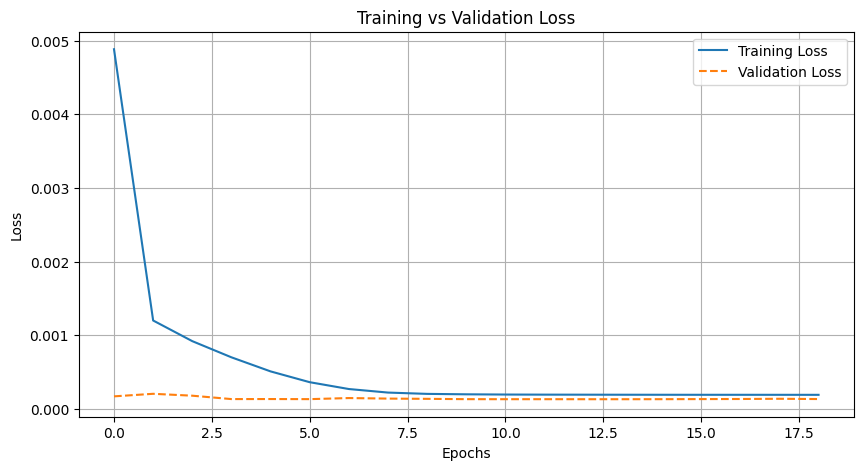

In [14]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### Save the fitted scaler and the model

In [15]:
# Relative path 
relative_path = "/Users/alexzheng/Developer/GitHub/EC331-project/EMH/models/"

In [16]:
import joblib

# Save model and scaler in a 'models' directory
gru_model.save(f"{relative_path}gru_model_1.keras")  # Saves architecture + weights
joblib.dump(scaler, f"{relative_path}scaler_1.pkl")  # Saves fitted scaler

['/Users/alexzheng/Developer/GitHub/EC331-project/EMH/models/scaler_1.pkl']

## Evaluation

In [17]:
# from keras.models import load_model

# # Load trained model
# gru_model = load_model(f"{relative_path}gru_model_1.keras")

# # Load trained scaler
# scaler = joblib.load(f"{relative_path}scaler_1.pkl")

In [18]:
# Crate an inverse function
def inverse_transform_predictions(predicted_scaled, y_actual_scaled, scaler, train_data, target_col_idx):
    """
    Inverse transforms the scaled predictions and actual values back to the original scale.

    Parameters:
    - predicted_scaled: Model predictions in scaled form (shape: (n_samples, 1)).
    - y_actual_scaled: Actual target values in scaled form (shape: (n_samples,)).
    - scaler: The MinMaxScaler fitted on the training data.
    - train_data: The original training dataset (used to get the number of features for inverse transform).
    - target_col_idx: The index of the target column in the dataset.

    Returns:
    - predicted_inverse: Predictions in the original scale.
    - y_actual_inverse: Actual values in the original scale.
    """

    # Create full arrays with the same shape as train_data for inverse transformation
    predicted_full = np.zeros((predicted_scaled.shape[0], train_data.shape[1]))
    y_actual_full = np.zeros((y_actual_scaled.shape[0], train_data.shape[1]))

    # Fill only the target column (Returns%)
    predicted_full[:, target_col_idx] = predicted_scaled[:, 0]  # Ensure correct shape
    y_actual_full[:, target_col_idx] = y_actual_scaled  # y_actual is already 1D

    # Apply inverse transform
    predicted_inverse = scaler.inverse_transform(predicted_full)[:, target_col_idx]
    y_actual_inverse = scaler.inverse_transform(y_actual_full)[:, target_col_idx]

    return predicted_inverse, y_actual_inverse

### Training set evaluation

In [19]:
# Get inverse transformed predictions and actual values
predicted_train_inverse, y_train_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_train),
    y_actual_scaled=y_train,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

11140/11140 ━━━━━━━━━━━━━━━━━━━━ 67s 6ms/step


In [20]:
# Compute error metrics for the training set
mae_train = mean_absolute_error(y_train_inverse, predicted_train_inverse)
rmse_train = sqrt(mean_squared_error(y_train_inverse, predicted_train_inverse))
mape_train = np.mean(np.abs((y_train_inverse - predicted_train_inverse) / y_train_inverse)) * 100

print(f"Train MAE: {mae_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAPE: {mape_train:.2f}%")

Train MAE: 0.0484
Train RMSE: 0.0785
Train MAPE: inf%


### Validation set evaluation

In [21]:
# Get inverse transformed predictions and actual values
predicted_val_inverse, y_val_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_val),
    y_actual_scaled=y_val,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

3182/3182 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step


In [22]:
# Compute error metrics for the val set
mae_val = mean_absolute_error(y_val_inverse, predicted_val_inverse)
rmse_val = sqrt(mean_squared_error(y_val_inverse, predicted_val_inverse))
mape_val = np.mean(np.abs((y_val_inverse - predicted_val_inverse) / y_val_inverse)) * 100

print(f"Validation MAE: {mae_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Validation MAPE: {mape_val:.2f}%")

Validation MAE: 0.0415
Validation RMSE: 0.0651
Validation MAPE: inf%


### Test set evaluation

In [ ]:
# Get inverse transformed predictions and actual values
predicted_test_inverse, y_test_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_test),
    y_actual_scaled=y_test,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

1590/1590 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step


In [ ]:
# Compute error metrics for the test set
mae_test = mean_absolute_error(y_test_inverse, predicted_test_inverse)
rmse_test = sqrt(mean_squared_error(y_test_inverse, predicted_test_inverse))
mape_test = np.mean(np.abs((y_test_inverse - predicted_test_inverse) / y_test_inverse)) * 100

print(f"Test MAE: {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAPE: {mape_test:.2f}%")

Test MAE: 0.0479
Test RMSE: 0.0750
Test MAPE: inf%


In [ ]:
# # Extract date index for plotting
# date_index = val_data.index[window_size:]  # Align with sequence offset

# # Plot actual vs predicted Returns% for validation set
# plt.figure(figsize=(12, 6))
# plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
# plt.plot(date_index, predicted_val_inverse, label='Predicted (Validation)', linestyle='dashed')

# plt.title('Actual vs Predicted Returns% (Validation Set)')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# plt.xticks(rotation=45)
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# # Extract date index for plotting
# date_index = test_data.index[window_size:]  # Align with sequence offset

# # Plot actual vs predicted Returns% for test set
# plt.figure(figsize=(12, 6))
# plt.plot(date_index, y_test_inverse, label='Actual (Test)')
# plt.plot(date_index, predicted_test_inverse, label='Predicted (Test)', linestyle='dashed')

# plt.title('Actual vs Predicted Returns% (Test Set)')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# plt.xticks(rotation=45)
# plt.legend()
# plt.grid(True)
# plt.show()

## Benchmark - Naïve Forecast

In [25]:
actual_val = val_data['Returns%']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_val.iloc[window_size - 1:-1].values
actual_val_values = actual_val.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_val_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_val_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_val_values - naive_predictions) / actual_val_values)) * 100

print(f"Validation Naive MAE: {mae_naive:.4f}")
print(f"Validation Naive RMSE: {rmse_naive:.4f}")
print(f"Validation Naive MAPE: {mape_naive:.2f}%")

Validation Naive MAE: 0.0601
Validation Naive RMSE: 0.0918
Validation Naive MAPE: nan%


In [31]:
actual_test = test_data['Returns%']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_test.iloc[window_size - 1:-1].values
actual_test_values = actual_test.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_test_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_test_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_test_values - naive_predictions) / actual_test_values)) * 100

print(f"Test Naive MAE: {mae_naive:.4f}")
print(f"Test Naive RMSE: {rmse_naive:.4f}")
print(f"Test Naive MAPE: {mape_naive:.2f}%")

Test Naive MAE: 0.0698
Test Naive RMSE: 0.1064
Test Naive MAPE: nan%


In [ ]:
# # Prepare a date index for plotting (adjusting for the sequence offset)
# date_index = val_data.index[window_size:]

# plt.figure(figsize=(12, 6))
# plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
# plt.plot(date_index, predicted_val_inverse, label='GRU Predictions (Validation)', linestyle='dashed')
# plt.plot(date_index, naive_predictions, label='Naive Predictions (Validation)', linestyle='dotted')
# plt.title('Actual vs GRU and Naive Predictions (Validation Set)')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.xticks(rotation=45)
# plt.legend()
# plt.grid(True)
# plt.show()

In [34]:
# # Prepare a date index for plotting (adjusting for the sequence offset)
# date_index = test_data.index[window_size:]

# plt.figure(figsize=(12, 6))
# plt.plot(date_index, y_test_inverse, label='Actual (Test)')
# plt.plot(date_index, predicted_test_inverse, label='GRU Predictions (Test)', linestyle='dashed')
# plt.plot(date_index, naive_predictions, label='Naive Predictions (Test)', linestyle='dotted')
# plt.title('Actual vs GRU and Naive Predictions (Test Set)')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.xticks(rotation=45)
# plt.legend()
# plt.grid(True)
# plt.show()